# dim_red — load weighted HKS, subsample, cluster + reduce

Loads precomputed per-feature HKS weights (from `optimize_hks_weights.py`), applies
them, subsamples high-complexity organoids, clusters in the **weighted-HKS space**
(not chamfer), and embeds in 2D. No weight optimisation here.

In [538]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import kneighbors_graph
import umap

from src import utils
importlib.reload(utils)

<module 'src.utils' from '/Users/yuli/Documents/Code/SphericalHarmonics/src/utils.py'>

In [ ]:
# === VERSION toggle =========================================================
# Switch the whole notebook between the two parallel lineages:
#   "new"    -> perturbation-inclusive vocab   (master.npz, hks_weights_full.npz,
#               chamfer_highcomplexity.npz, embeddings/)
#   "backup" -> old WT-only vocab              (master_backup.npz, hks_weights_full_backup.npz,
#               chamfer_highcomplexity_backup.npz, embeddings_backup/)
# Only master / weights / chamfer / emb_dir are version-specific; the fate CSVs
# and mesh_features are shared, so they keep using `path`.

import os
VERSION = "new"          # "new" | "backup"
_sfx    = {"new": "", "backup": "_backup"}[VERSION]

path = 'Data'
emb_dir      = f"{path}/embeddings{_sfx}"
master_path  = f"{path}/npz/master{_sfx}.npz"
weights_path = f"{path}/npz/hks_weights_full{_sfx}.npz"
chamfer_path = f"{path}/npz/chamfer_highcomplexity{_sfx}.npz"
os.makedirs(emb_dir, exist_ok=True)
print(f"VERSION={VERSION!r} | master={master_path} | weights={weights_path} | emb_dir={emb_dir}")

# --- load learned weights + metadata (from optimize_hks_weights.py) ---------
wf = np.load(weights_path, allow_pickle=True)
weights     = wf['weights']                 # (mode_cut, n_vocab)
mode_cut    = int(wf['mode_cut'])
trusted_ids = set(wf['trusted_ids'].astype(str))
print(f"weights {weights.shape} | mode_cut={mode_cut} | {len(trusted_ids)} trusted ids")

VERSION='new' | master=Data/npz/master.npz | weights=Data/npz/hks_weights_full.npz | emb_dir=Data/embeddings
weights (8, 8) | mode_cut=8 | 550 trusted ids


In [540]:
# --- load data + build weighted-HKS shape features -------------------------
master = np.load(master_path, allow_pickle=True)
filtered_ids        = master['ids'].astype(str)
filtered_datasets   = master['datasets'].astype(str)
filtered_times      = master['times'].astype(str)
filtered_conditions = master['conditions'].astype(str)
filtered_areas      = master['areas']
l_cross_values      = master['l_cross_values']

ids, hps = utils.load_power_spectrum(master_path, mode_cut=mode_cut)
assert np.array_equal(ids, filtered_ids)
features = utils.apply_hks_weights(hps, weights)        # (N, mode_cut*n_vocab)
print('organoids:', len(filtered_ids), '| weighted features:', features.shape)
print('conditions:', dict(zip(*np.unique(filtered_conditions, return_counts=True))))

organoids: 3662 | weighted features: (3662, 64)
conditions: {'WT': 3053, 'abs-Iwp2': 138, 'sec-DaptHi': 102, 'sec-DaptIwp2iMekD1': 118, 'stem-ChirVpaD1': 213, 'ta-Yapa': 38}


In [541]:
# --- fate-marker fractions (for colouring overlays) ------------------------
fate_ids, percentages, col_names = utils.load_fate_percentages(
    path, filtered_ids, filtered_datasets, update=False)

# exclude organoids absent from the fate CSV (detected via the npz cache, no CSV re-read)
in_fate = np.isin(filtered_ids, fate_ids)
n_excl  = int((~in_fate).sum())
print(f"excluded {n_excl}/{len(filtered_ids)} organoids absent from fate CSV "
      f"({in_fate.sum()} remaining)")
if n_excl:
    excl_t = filtered_times[~in_fate]
    uniq_excl, cnts_excl = np.unique(excl_t, return_counts=True)
    print("  by timepoint:", dict(zip(uniq_excl, cnts_excl)))

filtered_ids        = filtered_ids[in_fate]
filtered_datasets   = filtered_datasets[in_fate]
filtered_times      = filtered_times[in_fate]
filtered_conditions = filtered_conditions[in_fate]
filtered_areas      = filtered_areas[in_fate]
l_cross_values      = l_cross_values[in_fate]
features            = features[in_fate]
# percentages is already aligned to fate_ids = filtered_ids (post-filter)

# treat cells with no positive exclusive marker as their own 'neg' fate
neg = np.clip(1.0 - percentages.sum(1), 0.0, 1.0)
percentages = np.column_stack([percentages, neg])
col_names   = list(col_names) + ['neg']
perc_fields = {f"perc_{n}": percentages[:, j] for j, n in enumerate(col_names)}
print('cell types:', col_names)

excluded 0/3662 organoids absent from fate CSV (3662 remaining)
cell types: ['ABS', 'EC', 'EEPROG', 'PANETH', 'SECPROG', 'STEM', 'TA', 'neg']


In [542]:
# --- optional: stratified subsample, cap per timepoint ----------------------
# Caps the number of organoids per timepoint (in sorted-timepoint order) before
# the high-complexity subset + clustering, so over-represented timepoints don't
# dominate. Set SUBSAMPLE_BY_TIME = False to keep everything.
#
# Reproducibility: within each timepoint the candidates are sorted by uid BEFORE
# the seeded choice, so the selected SET is independent of master.npz row order
# (a full rebuild vs --update, or a discard, reorders rows but not the result).
SUBSAMPLE_BY_TIME = True
# one cap per np.unique(filtered_times): 1p5,2,2p5,3,3p5,4,4p5,4p5-more (pert is day 4p5)
samples_per_timepoint = [100, 100, 100, 100, 200, 2000, 2000, 2000]

if SUBSAMPLE_BY_TIME:
    rng = np.random.default_rng(42)
    uniq_t = np.unique(filtered_times)
    assert len(samples_per_timepoint) == len(uniq_t), \
        f"need one cap per timepoint {list(uniq_t)} ({len(uniq_t)} of them)"
    keep_parts = []
    for i, t in enumerate(uniq_t):
        idx_t = np.where(filtered_times == t)[0]
        idx_t = idx_t[np.argsort(filtered_ids[idx_t], kind='stable')]   # uid-sorted -> choice independent of row order
        n_t   = min(samples_per_timepoint[i], len(idx_t))
        keep_parts.append(idx_t[rng.choice(len(idx_t), size=n_t, replace=False)])
    keep_idx = np.sort(np.concatenate(keep_parts))
    filtered_ids        = filtered_ids[keep_idx]
    filtered_datasets   = filtered_datasets[keep_idx]
    filtered_times      = filtered_times[keep_idx]
    filtered_conditions = filtered_conditions[keep_idx]
    filtered_areas      = filtered_areas[keep_idx]
    l_cross_values      = l_cross_values[keep_idx]
    features            = features[keep_idx]
    percentages         = percentages[keep_idx]
    perc_fields         = {k: v[keep_idx] for k, v in perc_fields.items()}
    print(f"subsampled to {len(keep_idx)} organoids")
    print(pd.Series(filtered_times).value_counts().sort_index().to_string())

subsampled to 2481 organoids
1p5          100
2            100
2p5          100
3            100
3p5          200
4            343
4p5         1035
4p5-more     503


In [543]:
# --- restrict to high-complexity subset (mask applied to ALL variables) -----
# Apply the complexity mask once, here, so no downstream cell needs
# array[complexity_mask] again — every variable below is already the subset.
complexity_mask = l_cross_values >= 0
filtered_ids        = filtered_ids[complexity_mask]
filtered_datasets   = filtered_datasets[complexity_mask]
filtered_times      = filtered_times[complexity_mask]
filtered_conditions = filtered_conditions[complexity_mask]
filtered_areas      = filtered_areas[complexity_mask]
l_cross_values      = l_cross_values[complexity_mask]
features            = features[complexity_mask]
percentages         = percentages[complexity_mask]
perc_fields         = {k: v[complexity_mask] for k, v in perc_fields.items()}

# --- canonical ordering: sort the whole subset by uid ----------------------
# Makes the matrix handed to clustering / UMAP identical regardless of master.npz
# row order, so a rebuilt master (full rebuild vs --update, or after a discard)
# reproduces the same embedding. With the uid-stable subsample above, the run now
# depends only on the SET of organoids, not their file position.
order = np.argsort(filtered_ids, kind='stable')
filtered_ids        = filtered_ids[order]
filtered_datasets   = filtered_datasets[order]
filtered_times      = filtered_times[order]
filtered_conditions = filtered_conditions[order]
filtered_areas      = filtered_areas[order]
l_cross_values      = l_cross_values[order]
features            = features[order]
percentages         = percentages[order]
perc_fields         = {k: v[order] for k, v in perc_fields.items()}

shape_features = features          # weighted-HKS features for the subset
m_ids          = filtered_ids      # ids aligned to shape_features
print('subset:', shape_features.shape)

subset: (2481, 64)


In [544]:
# --- Hill numbers: cell-type diversity per organoid ------------------------
# Hill number of order q = effective number of cell types:
#   q != 1:  (sum_i p_i**q) ** (1 / (1 - q))
#   q == 1:  exp(-sum_i p_i ln p_i)              (exp of Shannon entropy)
# p_i = per-organoid cell-type abundances (fate fractions, row-normalised).
# q=0 -> diversity (# types present); larger q weights dominant types more.
hill_qs = np.array([0.0, 1.0])                    # diversity (q=0) and exp-Shannon (q=1)

def hill_numbers(p, qs):
    p = np.asarray(p, float)
    p = p / np.clip(p.sum(1, keepdims=True), 1e-12, None)    # -> relative abundances
    logp = np.log(p, out=np.zeros_like(p), where=p > 0)   # 0 where p==0 (no warning)
    out = np.empty((p.shape[0], len(qs)))
    for j, q in enumerate(qs):
        if np.isclose(q, 1.0):
            out[:, j] = np.exp(-(p * logp).sum(1))
        else:
            out[:, j] = np.where(p > 0, p ** q, 0.0).sum(1) ** (1.0 / (1.0 - q))
    return out

hill = hill_numbers(percentages, hill_qs)        # (n_subset, n_q), already masked
hill_fields = {f"hill_q{q:.2f}": hill[:, j] for j, q in enumerate(hill_qs)}
hill_div = hill[:, -1]                            # q=1 (exp-Shannon) for default colouring
print('Hill numbers:', hill.shape, '| q =', np.round(hill_qs, 2).tolist())

Hill numbers: (2481, 2) | q = [0.0, 1.0]


In [545]:
# --- cluster shape features (for colouring overlays) -----------------------

n_shape_clusters = 20
KNN_NEIGHBORS    = 7     # graph size for 'ward_knn' / 'spectral'
CLUSTER_ALGO     = 'spectral'     # 'ward' | 'spectral' | 'kmeans'
if CLUSTER_ALGO == 'ward':
    shape_clusters = AgglomerativeClustering(n_shape_clusters, linkage='ward').fit_predict(shape_features)
elif CLUSTER_ALGO == 'spectral':
    shape_clusters = SpectralClustering(n_shape_clusters, affinity='nearest_neighbors',
                                        n_neighbors=KNN_NEIGHBORS, assign_labels='discretize',
                                        random_state=42).fit_predict(shape_features)
else:
    shape_clusters = KMeans(n_shape_clusters, random_state=42, n_init=10).fit_predict(shape_features)
# relabel by descending size so colours are stable (biggest = 0)
order = {c: r for r, c in enumerate(pd.Series(shape_clusters).value_counts().index)}
shape_clusters = np.array([order[c] for c in shape_clusters])
print(f"{CLUSTER_ALGO}: {n_shape_clusters} clusters | sizes "
      f"{pd.Series(shape_clusters).value_counts().sort_index().tolist()}")

spectral: 20 clusters | sizes [304, 301, 198, 176, 152, 140, 139, 133, 125, 116, 107, 94, 92, 91, 80, 70, 59, 42, 40, 22]


In [546]:
# --- aggregate: collapse all low-complexity clusters into one (label 0) -----
# Clusters whose median l_cross < LOW_COMPLEXITY_THRESHOLD are "low-complexity" and
# merged into label 0; each remaining cluster keeps its own label, renumbered
# 1..n contiguously. Computed here (before the save_embedding calls below) so it
# can be written into every embedding npz and coloured in inspect_embedding as
# 'agg_cluster'.

LOW_COMPLEXITY_THRESHOLD = 5
aggregated_shape_clusters = np.zeros_like(shape_clusters)
for i in range(n_shape_clusters):
    cluster_mask = shape_clusters == i

    cluster_complexity = l_cross_values[cluster_mask]
    if np.percentile(cluster_complexity, 80) < LOW_COMPLEXITY_THRESHOLD:
        aggregated_shape_clusters[cluster_mask] = 0
    else:
        aggregated_shape_clusters[cluster_mask] = i + 1
# renumber to contiguous unique labels (0 = low-complexity, then 1..n)
unique_vals = np.unique(aggregated_shape_clusters)          # sorted, 0 first
remap = {v: j for j, v in enumerate(unique_vals)}
aggregated_shape_clusters = np.array([remap[v] for v in aggregated_shape_clusters])
n_agg_clusters = len(unique_vals)
print(f"aggregated: {n_agg_clusters} clusters (0=low-complexity) | sizes "
      f"{pd.Series(aggregated_shape_clusters).value_counts().sort_index().tolist()}")

# --- cluster centres (feature space) + per-organoid distance to its centre ---
# Centre = mean of the weighted-HKS features over each aggregated cluster.
# centre_dist[i] = || shape_features[i] - centre(cluster of i) ||, i.e. how far
# organoid i sits from its own cluster's centre (0 = at the centre). Saved into
# every embedding npz so the viewer / downstream can rank organoids by how
# representative they are; each cluster's minimum picks out its medoid.
cluster_centres = np.vstack([shape_features[aggregated_shape_clusters == c].mean(0)
                             for c in range(n_agg_clusters)])
centre_dist = np.linalg.norm(shape_features - cluster_centres[aggregated_shape_clusters], axis=1)
print(f"distance to cluster centre: mean {centre_dist.mean():.3f} | max {centre_dist.max():.3f}")

aggregated: 10 clusters (0=low-complexity) | sizes [1306, 304, 152, 140, 133, 116, 107, 92, 91, 40]
distance to cluster centre: mean 0.096 | max 0.422


In [547]:
# --- 2D embedding + save (self-contained for inspect_embedding.py) ---------
method = 'umap'
if method == 'umap':
    dim_red = umap.UMAP(n_components=2, random_state=42, n_neighbors=5, min_dist=1)
    hks_emb = dim_red.fit_transform(shape_features)
elif method == 'pca':
    from sklearn.decomposition import PCA
    dim_red = PCA(n_components=2)   
    hks_emb = dim_red.fit_transform(shape_features)

# per-point overlays: uid_group (0=none, g+1=group g) and trusted (weight-supervision set)
m_pos = {u: i for i, u in enumerate(m_ids)}
uid_group_field = np.zeros(len(m_ids))
for gi, grp in enumerate(utils.UID_GROUPS):
    for u in grp:
        if u in m_pos:
            uid_group_field[m_pos[u]] = gi + 1
trusted_field = np.array([1.0 if u in trusted_ids else 0.0 for u in m_ids])

/opt/homebrew/anaconda3/envs/scmpx/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [548]:
filename = "hks_emb"

utils.save_embedding(emb_dir, filename, hks_emb, m_ids, method,
                     times=filtered_times, condition=filtered_conditions, l_cross=l_cross_values,
                     areas=filtered_areas, shape_cluster=shape_clusters,
                     agg_cluster=aggregated_shape_clusters, centre_dist=centre_dist,
                     uid_group=uid_group_field, trusted=trusted_field, 
                     **perc_fields, **hill_fields)
print('saved', f"{emb_dir}/{filename}")

saved Data/embeddings/hks_emb


In [549]:
emb = np.load(f"{emb_dir}/{filename}.npz", allow_pickle=True)
# print all keys in emb 
print('keys in emb:', list(emb.keys()))

keys in emb: ['xy', 'ids', 'method', 'name', 'times', 'condition', 'l_cross', 'areas', 'shape_cluster', 'agg_cluster', 'centre_dist', 'uid_group', 'trusted', 'perc_ABS', 'perc_EC', 'perc_EEPROG', 'perc_PANETH', 'perc_SECPROG', 'perc_STEM', 'perc_TA', 'perc_neg', 'hill_q0.00', 'hill_q1.00']


/var/folders/5n/0rvnm9350db7gk5vdnj3tn6h0000gn/T/ipykernel_68036/1576184337.py:59: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/opt/homebrew/anaconda3/envs/scmpx/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


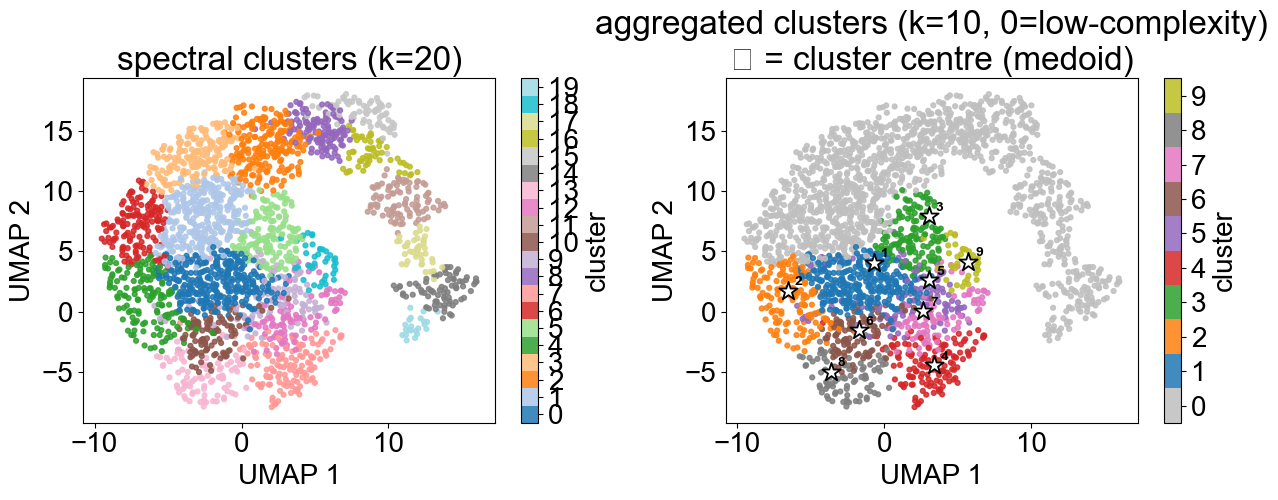

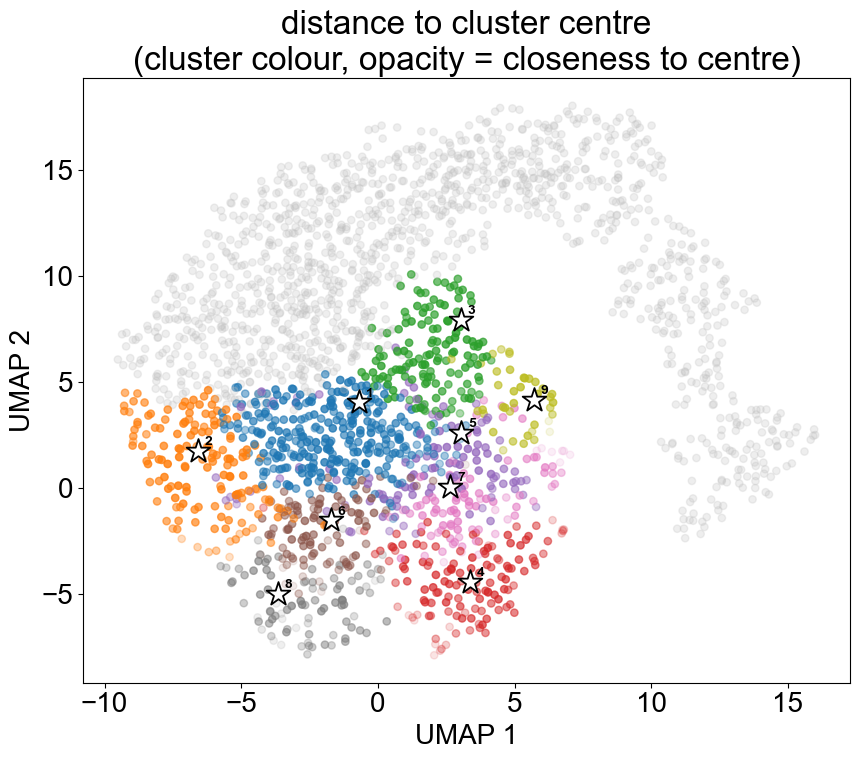

In [550]:
point_size = 12

def make_cluster_cmap(n):
    if n <= 10:   return 'tab10'
    if n <= 20:   return 'tab20'
    return plt.cm.colors.ListedColormap(plt.get_cmap('gist_ncar')(np.linspace(0, 1, n)))

def make_agg_cmap(n_agg):
    """Gray for cluster 0 (low-complexity), then distinct colours for 1..n."""
    n_high = n_agg - 1
    if n_high <= 10:
        hi_colors = plt.get_cmap('tab10')(np.arange(n_high) / 10)
    elif n_high <= 20:
        hi_colors = plt.get_cmap('tab20')(np.arange(n_high) / 20)
    else:
        hi_colors = plt.get_cmap('gist_ncar')(np.linspace(0, 1, n_high))
    gray = np.array([[0.75, 0.75, 0.75, 1.0]])
    return plt.cm.colors.ListedColormap(np.vstack([gray, hi_colors]))

agg_cmap = make_agg_cmap(n_agg_clusters)

# medoid of each high-complexity cluster = the organoid nearest its centre
# (min centre_dist). Its embedded position is a real point that sits inside the
# cluster, so it marks the centre far more honestly than UMAP-transforming the
# feature-space mean (a non-linear map can push that mean outside the cluster).
medoid_idx = {c: np.where(aggregated_shape_clusters == c)[0][
                  np.argmin(centre_dist[aggregated_shape_clusters == c])]
              for c in range(1, n_agg_clusters)}

def mark_centres(ax, size=190):
    """Star + cluster-number label at each high-complexity cluster's medoid."""
    for c, mi in medoid_idx.items():
        ax.scatter(*hks_emb[mi], marker='*', s=size, c='white',
                   edgecolors='black', linewidths=1.3, zorder=6)
        ax.annotate(str(c), hks_emb[mi], textcoords='offset points', xytext=(5, 4),
                    fontsize=10, fontweight='bold', zorder=7)

# === figure 1: raw + aggregated clusters ===================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))

# raw shape clusters
sc0 = axes[0].scatter(hks_emb[:, 0], hks_emb[:, 1], c=shape_clusters,
                      cmap=make_cluster_cmap(n_shape_clusters),
                      vmin=-0.5, vmax=n_shape_clusters - 0.5, s=point_size, alpha=0.85)
axes[0].set_title(f'{CLUSTER_ALGO} clusters (k={n_shape_clusters})')
fig.colorbar(sc0, ax=axes[0], ticks=range(n_shape_clusters), label='cluster')

# aggregated clusters + numbered centre (medoid) markers
sc1 = axes[1].scatter(hks_emb[:, 0], hks_emb[:, 1], c=aggregated_shape_clusters,
                      cmap=agg_cmap, vmin=-0.5, vmax=n_agg_clusters - 0.5,
                      s=point_size, alpha=0.85)
mark_centres(axes[1])
axes[1].set_title(f'aggregated clusters (k={n_agg_clusters}, 0=low-complexity)\n'
                  '★ = cluster centre (medoid)')
fig.colorbar(sc1, ax=axes[1], ticks=range(n_agg_clusters), label='cluster')

for ax in axes:
    ax.set_xlabel(f'{method.upper()} 1'); ax.set_ylabel(f'{method.upper()} 2')
plt.tight_layout(); plt.show()

# === figure 2: distance to cluster centre (its own larger plot) ============
# Same cluster colours as above, but each point's opacity fades with its
# distance from the cluster centre (opaque = at the centre, transparent = far).
hi = aggregated_shape_clusters > 0
rgba = np.asarray(agg_cmap(aggregated_shape_clusters), float).copy()   # per-point cluster colour
ALPHA_MIN = 0.12
vmax = np.percentile(centre_dist[hi], 98)          # robust to a few far outliers
frac = np.clip(centre_dist / vmax, 0, 1)           # 0 at centre -> 1 far
rgba[hi, 3] = 1.0 - (1.0 - ALPHA_MIN) * frac[hi]   # fade high-complexity by distance
rgba[~hi, 3] = 0.25                                 # low-complexity catch-all: faint, fixed

fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(hks_emb[:, 0], hks_emb[:, 1], c=rgba, s=28)
mark_centres(ax, size=320)
ax.set_title('distance to cluster centre\n(cluster colour, opacity = closeness to centre)')
ax.set_xlabel(f'{method.upper()} 1'); ax.set_ylabel(f'{method.upper()} 2')
plt.tight_layout(); plt.show()

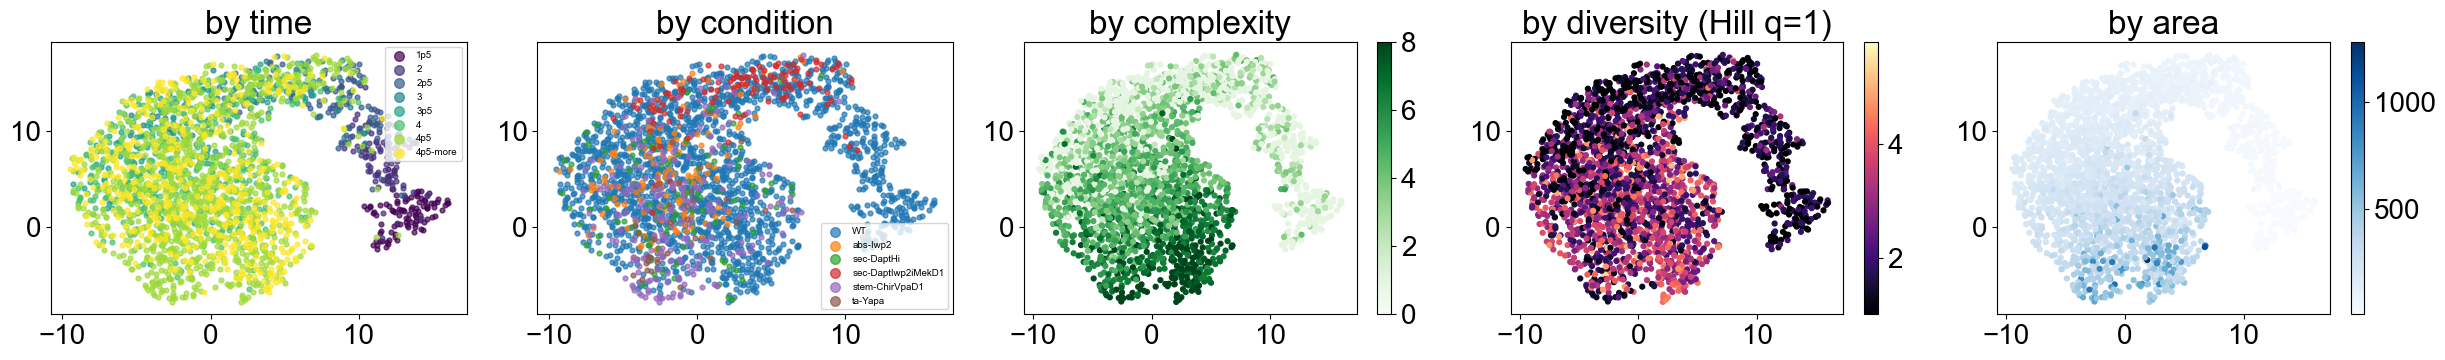

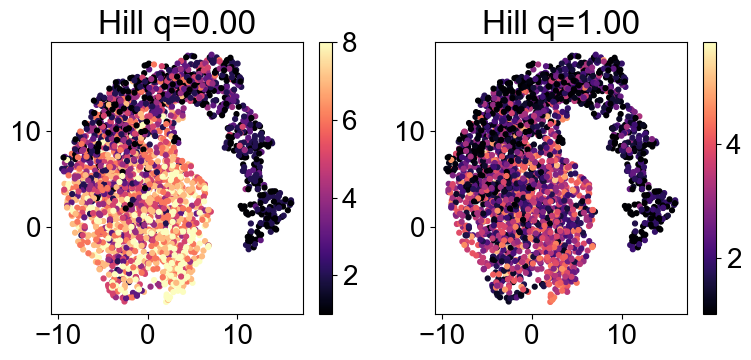

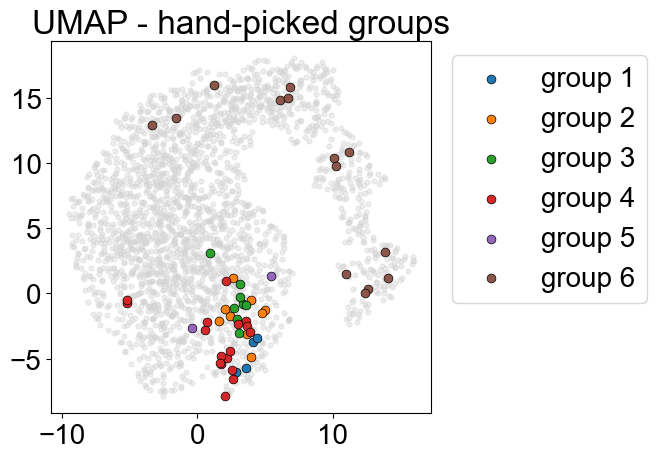

In [551]:
# --- embedding by time / condition / complexity / diversity / area, and groups
fig, axes = plt.subplots(1, 5, figsize=(25, 4))
uniq_t = np.unique(filtered_times); cmap_t = plt.get_cmap('viridis')
for i, t in enumerate(uniq_t):
    mk = filtered_times == t
    axes[0].scatter(hks_emb[mk, 0], hks_emb[mk, 1], color=cmap_t(i / max(1, len(uniq_t) - 1)),
                    s=point_size, alpha=0.7, label=t)
axes[0].set_title('by time'); axes[0].legend(markerscale=2, fontsize=7)
# condition is categorical (WT + pert drug tokens) -> one colour + legend per level
uniq_c = np.unique(filtered_conditions); cmap_c = plt.get_cmap('tab10')
for i, cnd in enumerate(uniq_c):
    mk = filtered_conditions == cnd
    axes[1].scatter(hks_emb[mk, 0], hks_emb[mk, 1], color=cmap_c(i % 10),
                    s=point_size, alpha=0.7, label=cnd)
axes[1].set_title('by condition'); axes[1].legend(markerscale=2, fontsize=7)
sc = axes[2].scatter(hks_emb[:, 0], hks_emb[:, 1], c=l_cross_values, cmap='Greens', s=point_size, vmin=0, vmax=8)
axes[2].set_title('by complexity'); fig.colorbar(sc, ax=axes[2])
sc = axes[3].scatter(hks_emb[:, 0], hks_emb[:, 1], c=hill_div, cmap='magma', s=point_size)
axes[3].set_title('by diversity (Hill q=1)'); fig.colorbar(sc, ax=axes[3])
sc = axes[4].scatter(hks_emb[:, 0], hks_emb[:, 1], c=filtered_areas, cmap='Blues', s=point_size)
axes[4].set_title('by area'); fig.colorbar(sc, ax=axes[4])
plt.tight_layout(); plt.show()

# --- diversity across the range of Hill orders q ---------------------------
fig, axes = plt.subplots(1, len(hill_qs), figsize=(4 * len(hill_qs), 4))
for j, q in enumerate(hill_qs):
    sc = axes[j].scatter(hks_emb[:, 0], hks_emb[:, 1], c=hill[:, j], cmap='magma', s=point_size)
    axes[j].set_title(f'Hill q={q:.2f}'); fig.colorbar(sc, ax=axes[j])
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(hks_emb[:, 0], hks_emb[:, 1], color='lightgrey', s=point_size, alpha=0.4)
for gi, grp in enumerate(utils.UID_GROUPS):
    mk = np.isin(m_ids, grp)
    if mk.any():
        ax.scatter(hks_emb[mk, 0], hks_emb[mk, 1], color=plt.get_cmap('tab10')(gi), s=40,
                   edgecolors='black', linewidths=0.5, label=f'group {gi + 1}')
ax.set_title(f'{method.upper()} - hand-picked groups'); ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

/var/folders/5n/0rvnm9350db7gk5vdnj3tn6h0000gn/T/ipykernel_68036/57687228.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=6.5, frameon=False, loc='upper left')


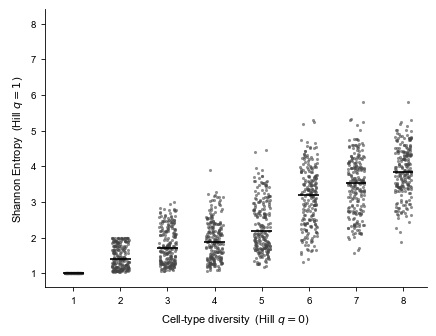

In [552]:
# --- Hill diversity: q=0 (diversity) vs q=1 (exp-Shannon) — publication plot -
rng_plot = np.random.default_rng(7)

q0 = hill[:, 0].astype(int)
q1 = hill[:, 1]
diversity_levels = sorted(set(q0))

plt.rcParams.update({'font.size': 20, 'font.family': 'Arial'})

fig, ax = plt.subplots(figsize=(4.5, 3.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

JITTER = 0.18
PT_SIZE = 5.0
MAX_STRIP = 220

for r in diversity_levels:
    vals = q1[q0 == r]
    n = min(len(vals), MAX_STRIP)
    sub = rng_plot.choice(len(vals), size=n, replace=False)
    jx = r + rng_plot.uniform(-JITTER, JITTER, size=n)
    ax.scatter(jx, vals[sub], s=PT_SIZE, color='#444444', alpha=0.6,
               linewidths=0, zorder=3)
    ax.hlines(np.median(vals), r - 0.22, r + 0.22, color='black', lw=1.2, zorder=4)

ax.set_xticks(diversity_levels)
ax.set_xlim(0.4, max(diversity_levels) + 0.5)
ax.set_ylim(0.6, max(diversity_levels) + 0.4)
ax.set_xlabel('Cell-type diversity  (Hill $q=0$)', fontsize=8, labelpad=4)
ax.set_ylabel('Shannon Entropy  (Hill $q=1$)', fontsize=8, labelpad=4)
ax.tick_params(axis='both', labelsize=7, length=3, width=0.6)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(0.6)
ax.legend(fontsize=6.5, frameon=False, loc='upper left')

plt.tight_layout(pad=0.6)
plt.savefig('Figures/hill_diversity.pdf', dpi=300, bbox_inches='tight')
plt.savefig('Figures/hill_diversity.png', dpi=300, bbox_inches='tight')
plt.show()

## Baselines: classical mesh features, and HKS + classical combined

Embed the same organoids three ways and compare:
1. **weighted HKS** (above),
2. **classical** hand-engineered descriptors from `mesh_features.csv` (volume,
   surface area, sphericity, extent, solidity, concavity, asymmetry, aspect
   ratio, SA:V),
3. **HKS + classical** combined (each blob balanced by its average per-organoid
   norm; HKS weights preserved).

The final figure overlays all three, coloured by time, complexity, and the
clusters found on the **HKS features only** — does HKS separate time / shape more
cleanly, and does adding classical features help?

In [553]:
# === classical (mesh_features.csv) UMAP — baseline to compare vs HKS ========
from sklearn.preprocessing import StandardScaler

CLASSIC_COLS = ['volume', 'surface_area', 'sphericity', 'extent', 'solidity',
                'concavity', 'asymmetry', 'aspect_ratio', 'sa_to_vol_ratio_norm']

def load_mesh_features(ids, datasets, cols=CLASSIC_COLS, root=path):
    """Classical mesh features aligned row-wise to `ids` -> (N, len(cols))."""
    tabs = {d: pd.read_csv(f"{root}/{d}/feature_tables/mesh_features.csv")
                 .set_index('label_uid') for d in sorted(set(datasets))}
    out = np.full((len(ids), len(cols)), np.nan)
    for i, (u, d) in enumerate(zip(ids, datasets)):
        bare = u[len(d) + 1:]
        if d in tabs and bare in tabs[d].index:
            out[i] = tabs[d].loc[bare, cols].to_numpy(float)
    return out

classic = load_mesh_features(m_ids, filtered_datasets)
assert not np.isnan(classic).any(), \
    f"{int(np.isnan(classic).any(1).sum())} organoids missing from mesh_features.csv"
classic_z = StandardScaler().fit_transform(classic)   # columns span very different scales
print('classical features:', classic.shape, '| cols:', CLASSIC_COLS)

mesh_emb = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=1).fit_transform(classic_z)

# same overlays as the HKS embedding so inspect_embedding shows them identically
utils.save_embedding(emb_dir, "mesh_feat_emb", mesh_emb, m_ids, 'umap',
                     times=filtered_times, condition=filtered_conditions, l_cross=l_cross_values,
                     areas=filtered_areas, shape_cluster=shape_clusters,
                     agg_cluster=aggregated_shape_clusters, centre_dist=centre_dist,
                     uid_group=uid_group_field, trusted=trusted_field,
                     **perc_fields, **hill_fields)
print('saved', f"{emb_dir}/mesh_feat_emb")

classical features: (2481, 9) | cols: ['volume', 'surface_area', 'sphericity', 'extent', 'solidity', 'concavity', 'asymmetry', 'aspect_ratio', 'sa_to_vol_ratio_norm']


/opt/homebrew/anaconda3/envs/scmpx/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


saved Data/embeddings/mesh_feat_emb


In [554]:
# === all features: weighted HKS + classical mesh_features ==================
# Combine both descriptor blobs. To stop one blob from dominating the joint
# distance purely by magnitude, each blob is divided by the *average L2 norm of
# its per-organoid vectors* (a single scalar per blob) before concatenating.
#   - HKS blob: the already weighted shape_features — only an overall scalar is
#     applied, so the learned per-feature HKS weights are preserved.
#   - classical blob: the standardized mesh_features (classic_z), so each of the
#     9 columns contributes rather than volume/area swamping the rest.

def blob_normalize(X):
    """Divide a feature blob by the mean L2 norm of its per-organoid vectors."""
    return X / np.linalg.norm(X, axis=1).mean()

hks_blob = blob_normalize(shape_features)   # weighted HKS, weights preserved
cls_blob = blob_normalize(classic_z)        # standardized classical features
all_features = np.hstack([hks_blob, cls_blob])
print('combined features:', all_features.shape,
      f'(HKS {hks_blob.shape[1]} + classical {cls_blob.shape[1]})')

all_emb = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=1).fit_transform(all_features)

# same overlays as the other embeddings so inspect_embedding shows them identically
utils.save_embedding(emb_dir, "all_feat_emb", all_emb, m_ids, 'umap',
                     times=filtered_times, condition=filtered_conditions, l_cross=l_cross_values,
                     areas=filtered_areas, shape_cluster=shape_clusters,
                     agg_cluster=aggregated_shape_clusters, centre_dist=centre_dist,
                     uid_group=uid_group_field, trusted=trusted_field,
                     **perc_fields, **hill_fields)
print('saved', f"{emb_dir}/all_feat_emb")

combined features: (2481, 73) (HKS 64 + classical 9)


/opt/homebrew/anaconda3/envs/scmpx/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


saved Data/embeddings/all_feat_emb


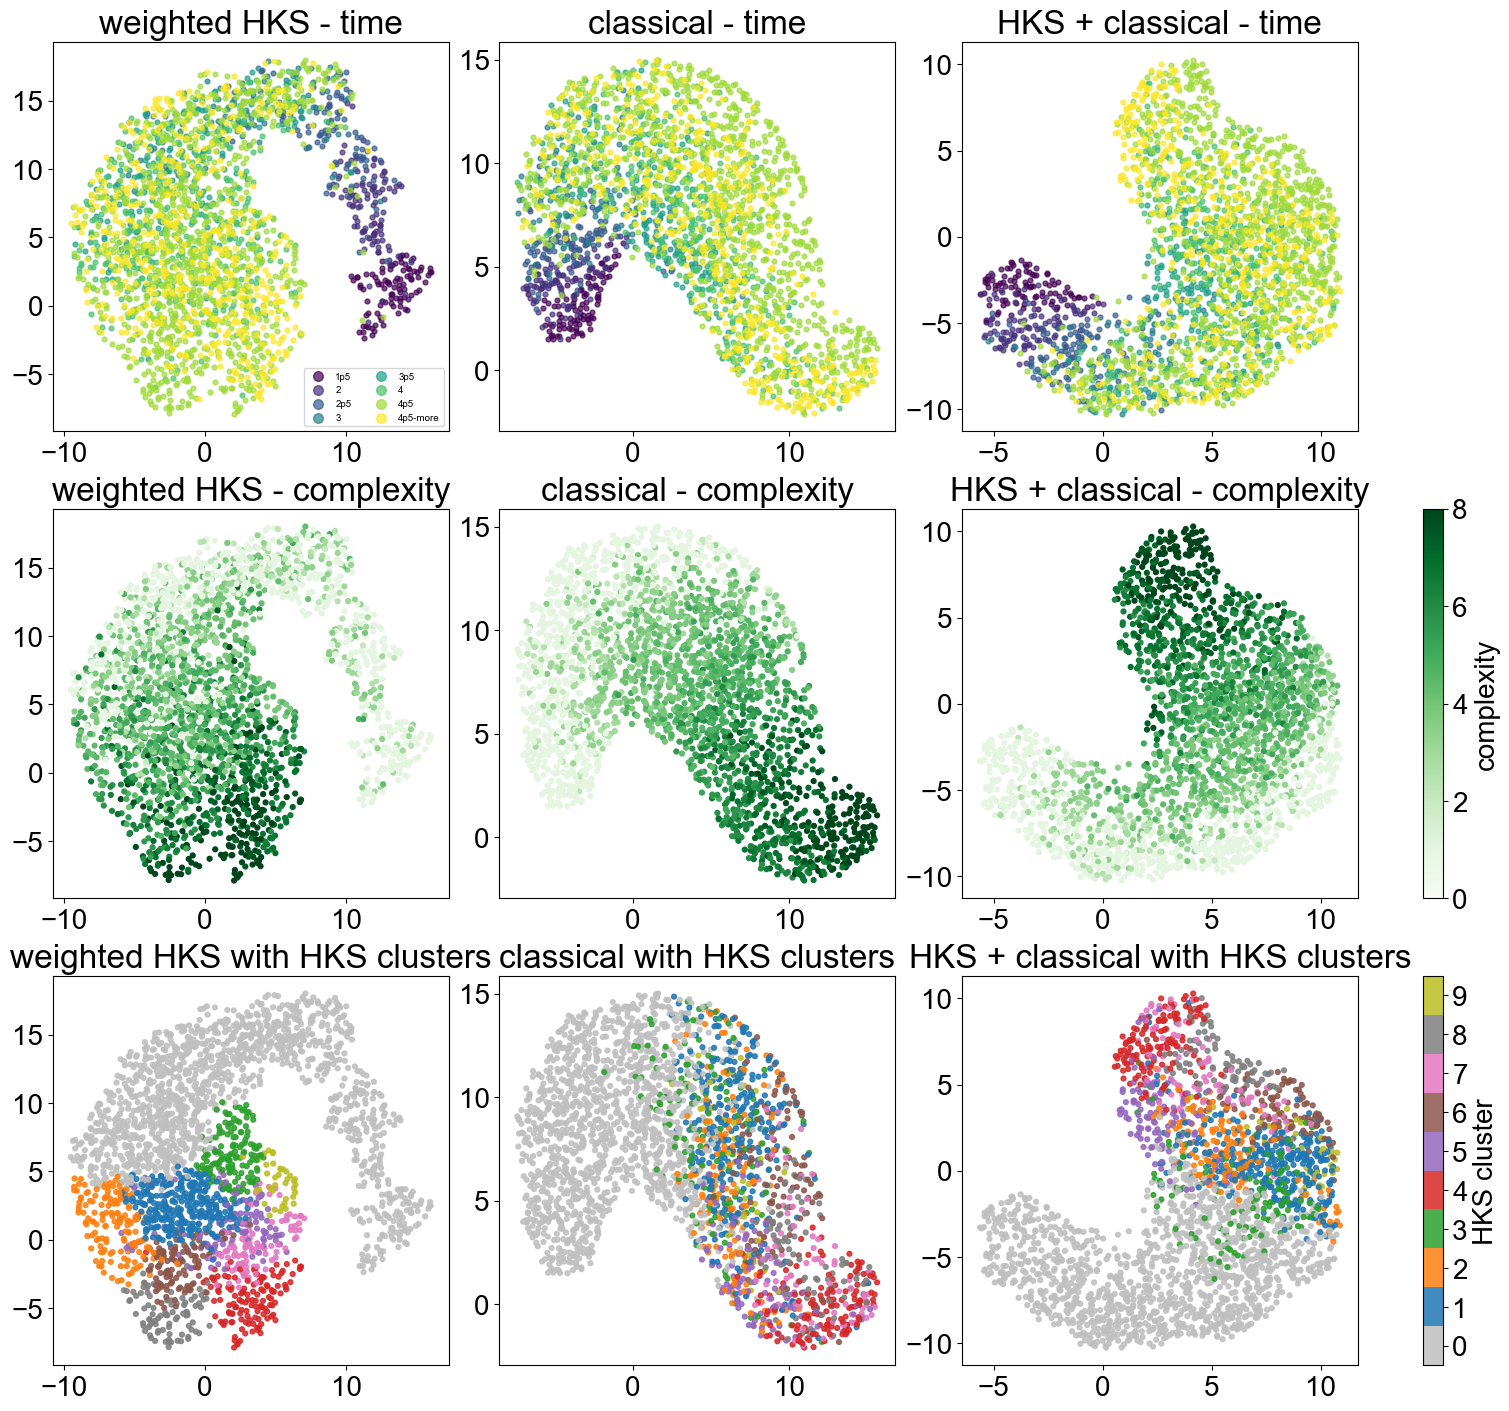

In [555]:
# --- three-way comparison: HKS vs classical vs combined --------------------
# cols = embedding (weighted HKS, classical, HKS+classical);
# rows = colouring: time, complexity, and the clusters found on HKS features ONLY
# (same shape_clusters in every panel), so you can see whether the time / shape
# structure HKS captures survives or improves when classical features are added.
embs = [(hks_emb, 'weighted HKS'), (mesh_emb, 'classical'), (all_emb, 'HKS + classical')]
uniq_t = np.unique(filtered_times); cmap_t = plt.get_cmap('viridis')

fig, axes = plt.subplots(3, 3, figsize=(15, 14), constrained_layout=True)
for col, (emb2d, name) in enumerate(embs):
    # row 0 - by time
    for i, t in enumerate(uniq_t):
        mk_t = filtered_times == t
        axes[0, col].scatter(emb2d[mk_t, 0], emb2d[mk_t, 1],
                             color=cmap_t(i / max(1, len(uniq_t) - 1)),
                             s=point_size, alpha=0.7, label=t)
    axes[0, col].set_title(f'{name} - time')
    # row 1 - by complexity
    sc_c = axes[1, col].scatter(emb2d[:, 0], emb2d[:, 1], c=l_cross_values, cmap='Greens',
                                s=point_size, vmin=0, vmax=8)
    axes[1, col].set_title(f'{name} - complexity')
    # row 2 - by aggregated HKS shape clusters (gray = low-complexity)
    sc_k = axes[2, col].scatter(emb2d[:, 0], emb2d[:, 1], c=aggregated_shape_clusters,
                                cmap=make_agg_cmap(n_agg_clusters),
                                vmin=-0.5, vmax=n_agg_clusters - 0.5, s=point_size, alpha=0.85)
    axes[2, col].set_title(f'{name} with HKS clusters')
axes[0, 0].legend(markerscale=2, fontsize=7, ncol=2)
fig.colorbar(sc_c, ax=axes[1, :], label='complexity', fraction=0.025)
fig.colorbar(sc_k, ax=axes[2, :], ticks=range(n_agg_clusters), label='HKS cluster', fraction=0.025)
plt.show()

## Shape vs fate: distance comparison and co-embedding

Compare the **weighted-HKS shape** representation (`shape_features`) against the **cell-fate
composition** (`percentages`, fate fractions incl. the `neg` column). Fate fractions are
compositional (they live on the simplex), so distances are taken after an isometric-log-ratio
(ILR) transform — Euclidean distance in ILR space is the Aitchison distance on the simplex.

1. **shape distance vs fate distance** — two panels binned by timepoint (day1p5–3p5 vs day4
   onwards), each over within-bin pairs with its own Spearman, plus an overall Spearman.
2. **co-embedding** — embed both modalities jointly, each block scaled to unit mean pairwise
   distance so neither dominates; the 2×3 panel colours the
   joint embedding by time, condition (WT vs pert drug tokens), area, `l_cross` (from
   master.npz), and Hill q=0 diversity.

All inputs (`shape_features`, `percentages`, `l_cross_values`, `hill`, `m_ids`, `filtered_*`,
`shape_clusters`, `uid_group_field`, `trusted_field`) are the masked/subsampled subset above.

fate composition (2481, 8) -> ILR (2481, 7)
dist computations restricted to ('main_dataset', 'sup_dataset'): 1872/2481 organoids (609 excluded, e.g. 'pert')
overall Spearman(shape, fate) = -0.135 over 1,751,256 pairs


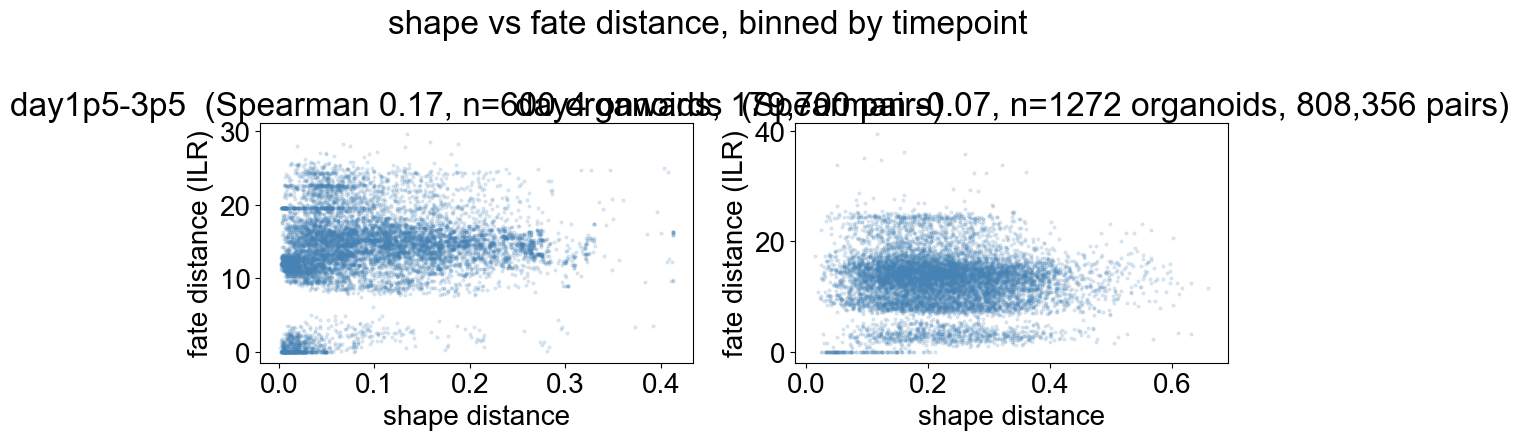

In [556]:
# --- fate composition -> ILR; shape vs fate distance, binned by timepoint ---
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr


def ilr_transform(P, eps=1e-6):
    """Isometric-log-ratio map of a composition (rows sum to 1) into R^(D-1).
    Euclidean distance in ILR space = Aitchison distance on the simplex — the
    geometry-aware way to compare fate compositions. Zeros are replaced
    multiplicatively so each row still sums to 1."""
    P = np.asarray(P, float)
    P = P / P.sum(1, keepdims=True)
    zero = P <= 0
    P = np.where(zero, eps, P * (1 - eps * zero.sum(1, keepdims=True)))
    clr = np.log(P) - np.log(P).mean(1, keepdims=True)
    D = P.shape[1]
    j = np.arange(1, D)
    a = 1.0 / np.sqrt(j * (j + 1))
    H = np.zeros((D, D - 1))                       # Helmert sub-basis (D, D-1)
    for c, (jj, aa) in enumerate(zip(j, a)):
        H[:jj, c] = aa
        H[jj, c]  = -jj * aa
    return clr @ H


fate_ilr = ilr_transform(percentages)             # percentages already carries the 'neg' column
print('fate composition', percentages.shape, '-> ILR', fate_ilr.shape)

# restrict the distance comparison below to non-perturbed data (drop 'pert')
DIST_DATASETS = ('main_dataset', 'sup_dataset')
dist_mask = np.isin(filtered_datasets, DIST_DATASETS)
print(f"dist computations restricted to {DIST_DATASETS}: {dist_mask.sum()}/{len(dist_mask)} "
      f"organoids ({int((~dist_mask).sum())} excluded, e.g. 'pert')")

dist_ids   = m_ids[dist_mask]
dist_times = filtered_times[dist_mask]
dist_shape = shape_features[dist_mask]
dist_fate  = fate_ilr[dist_mask]

# global pairwise distances (also reused to scale the co-embedding below)
shape_d = pdist(dist_shape)
fate_d  = pdist(dist_fate)
print(f"overall Spearman(shape, fate) = {spearmanr(shape_d, fate_d).correlation:.3f} "
      f"over {len(shape_d):,} pairs")

# two timepoint bins (master 'times' are 'day'-stripped: '1p5','2',...,'4p5-more')
time_bins = {
    'day1p5-3p5': ['1p5', '2', '2p5', '3', '3p5'],
    'day4 onwards': ['4', '4p5', '4p5-more'],
}
MIN_PAIRS = 100   # below this, a within-bin Spearman is too noisy to trust
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, (label, tps) in zip(axes, time_bins.items()):
    idx = np.where(np.isin(dist_times, tps))[0]
    sd  = pdist(dist_shape[idx])
    fd  = pdist(dist_fate[idx])
    n_organoids, n_pairs = len(idx), len(sd)
    assert n_pairs >= MIN_PAIRS, (
        f"{label}: only {n_pairs} pairs from {n_organoids} organoids "
        f"(need >= {MIN_PAIRS}) — too few to trust the within-bin Spearman")
    rho = spearmanr(sd, fd).correlation
    sub = rng.choice(n_pairs, size=min(10000, n_pairs), replace=False)
    ax.scatter(sd[sub], fd[sub], s=4, alpha=0.15, color='steelblue')
    ax.set_title(f'{label}  (Spearman {rho:.2f}, n={n_organoids} organoids, {n_pairs:,} pairs)')
    ax.set_xlabel('shape distance'); ax.set_ylabel('fate distance (ILR)')
plt.suptitle('shape vs fate distance, binned by timepoint')
plt.tight_layout()
plt.savefig('Figures/shape_vs_fate_distance.pdf', dpi=300, bbox_inches='tight')
plt.show()

# save just the per-organoid inputs needed to reproduce this figure — pairwise
# distances are O(n^2) (a uid-pair-per-entry version of this blew up past
# 700MB), but pdist() on these is deterministic and cheap to redo, so a
# collaborator regenerates shape_d/fate_d/the timepoint bins from this alone.
np.savez(f"sim/shape_fate_distance.npz",
         ids=dist_ids, times=dist_times,
         shape_features=dist_shape, fate_ilr=dist_fate,
         time_bin_labels=np.array(list(time_bins.keys()), dtype=object),
         time_bin_values=np.array(list(time_bins.values()), dtype=object))

In [557]:
m = np.load(f"sim/shape_fate_distance.npz", allow_pickle=True)
print('keys:', list(m.keys()))
print('ids', m['ids'].shape, '| shape_features', m['shape_features'].shape,
      '| fate_ilr', m['fate_ilr'].shape)

keys: ['ids', 'times', 'shape_features', 'fate_ilr', 'time_bin_labels', 'time_bin_values']
ids (1872,) | shape_features (1872, 64) | fate_ilr (1872, 7)


chamfer ids in current subset: 674/704
overall Spearman(chamfer, fate) = 0.036 over 226,801 pairs


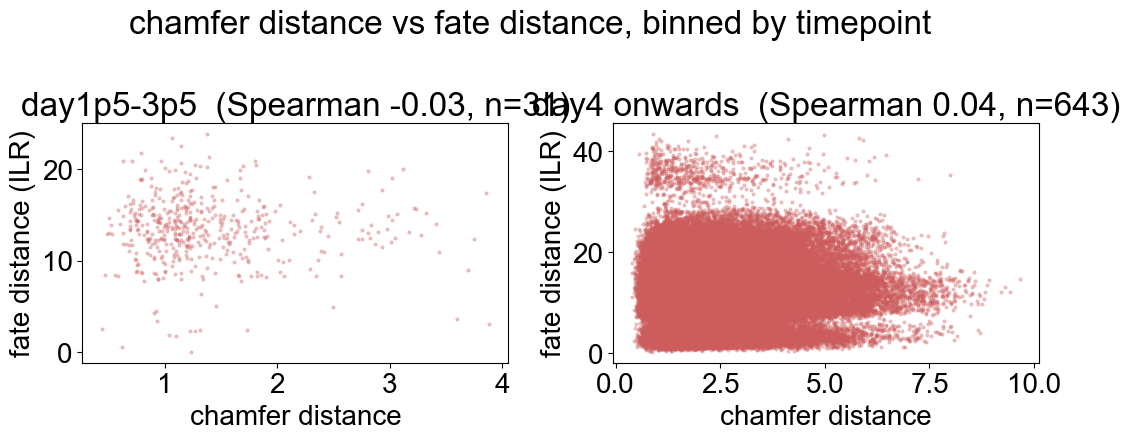

In [558]:
# --- chamfer distance vs fate distance (chamfer_highcomplexity.npz) --------
# Chamfer is only computed for the high-complexity organoids in compute_chamfer.py
# and is weak, trustworthy-when-small supervision (not ground truth). Restrict
# to the chamfer ids that also survive this notebook's subsample/complexity
# mask, then compare chamfer distance against fate ILR distance over the exact
# same pairs (mirrors the shape-vs-fate cell above).
ch      = np.load(chamfer_path, allow_pickle=True)
ch_ids  = ch['ids'].astype(str)
C       = ch['C']

m_pos    = {u: i for i, u in enumerate(m_ids)}
ch_keep  = np.array([u in m_pos for u in ch_ids])
ch_ids   = ch_ids[ch_keep]
C        = C[np.ix_(ch_keep, ch_keep)]
ch_rows  = np.array([m_pos[u] for u in ch_ids])
n_ch     = len(ch_ids)
print(f"chamfer ids in current subset: {n_ch}/{len(ch_keep)}")

iu_ch     = np.triu_indices(n_ch, k=1)
chamfer_d = C[iu_ch]
fate_d_ch = pdist(fate_ilr[ch_rows])
print(f"overall Spearman(chamfer, fate) = {spearmanr(chamfer_d, fate_d_ch).correlation:.3f} "
      f"over {len(chamfer_d):,} pairs")

ch_times = filtered_times[ch_rows]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, (label, tps) in zip(axes, time_bins.items()):
    idx = np.where(np.isin(ch_times, tps))[0]
    if len(idx) < 2:
        ax.set_title(f'{label}  (n={len(idx)}, too few)')
        continue
    cd  = C[np.ix_(idx, idx)][np.triu_indices(len(idx), k=1)]
    fd  = pdist(fate_ilr[ch_rows[idx]])
    rho = spearmanr(cd, fd).correlation
    ax.scatter(cd, fd, s=4, alpha=0.3, color='indianred')
    ax.set_title(f'{label}  (Spearman {rho:.2f}, n={len(idx)})')
    ax.set_xlabel('chamfer distance'); ax.set_ylabel('fate distance (ILR)')
plt.suptitle('chamfer distance vs fate distance, binned by timepoint')
plt.tight_layout()
plt.savefig('Figures/chamfer_vs_fate_distance.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [559]:
# --- co-embedding: scale each modality to unit mean pairwise distance, embed jointly --
# Dividing each block by its own mean pairwise distance puts shape and fate on a common
# scale, so the joint UMAP metric isn't dominated by whichever block has the larger spread.
shape_block = shape_features / shape_d.mean()
fate_block  = fate_ilr      / fate_d.mean()
joint_features = np.hstack([shape_block, fate_block])
print('joint features', joint_features.shape,
      f'(shape {shape_block.shape[1]} + fate {fate_block.shape[1]})')

shape_fate_emb = umap.UMAP(n_components=2, random_state=42,
                           n_neighbors=30, min_dist=1).fit_transform(joint_features)

# save with the same overlays as the other embeddings so inspect_embedding shows it identically
utils.save_embedding(emb_dir, "shape_fate_emb", shape_fate_emb, m_ids, 'umap',
                     times=filtered_times, condition=filtered_conditions, l_cross=l_cross_values,
                     areas=filtered_areas, shape_cluster=shape_clusters,
                     agg_cluster=aggregated_shape_clusters, centre_dist=centre_dist,
                     uid_group=uid_group_field, trusted=trusted_field,
                     **perc_fields, **hill_fields)
print('saved', f"{emb_dir}/shape_fate_emb")

joint features (2481, 71) (shape 64 + fate 7)


/opt/homebrew/anaconda3/envs/scmpx/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


saved Data/embeddings/shape_fate_emb


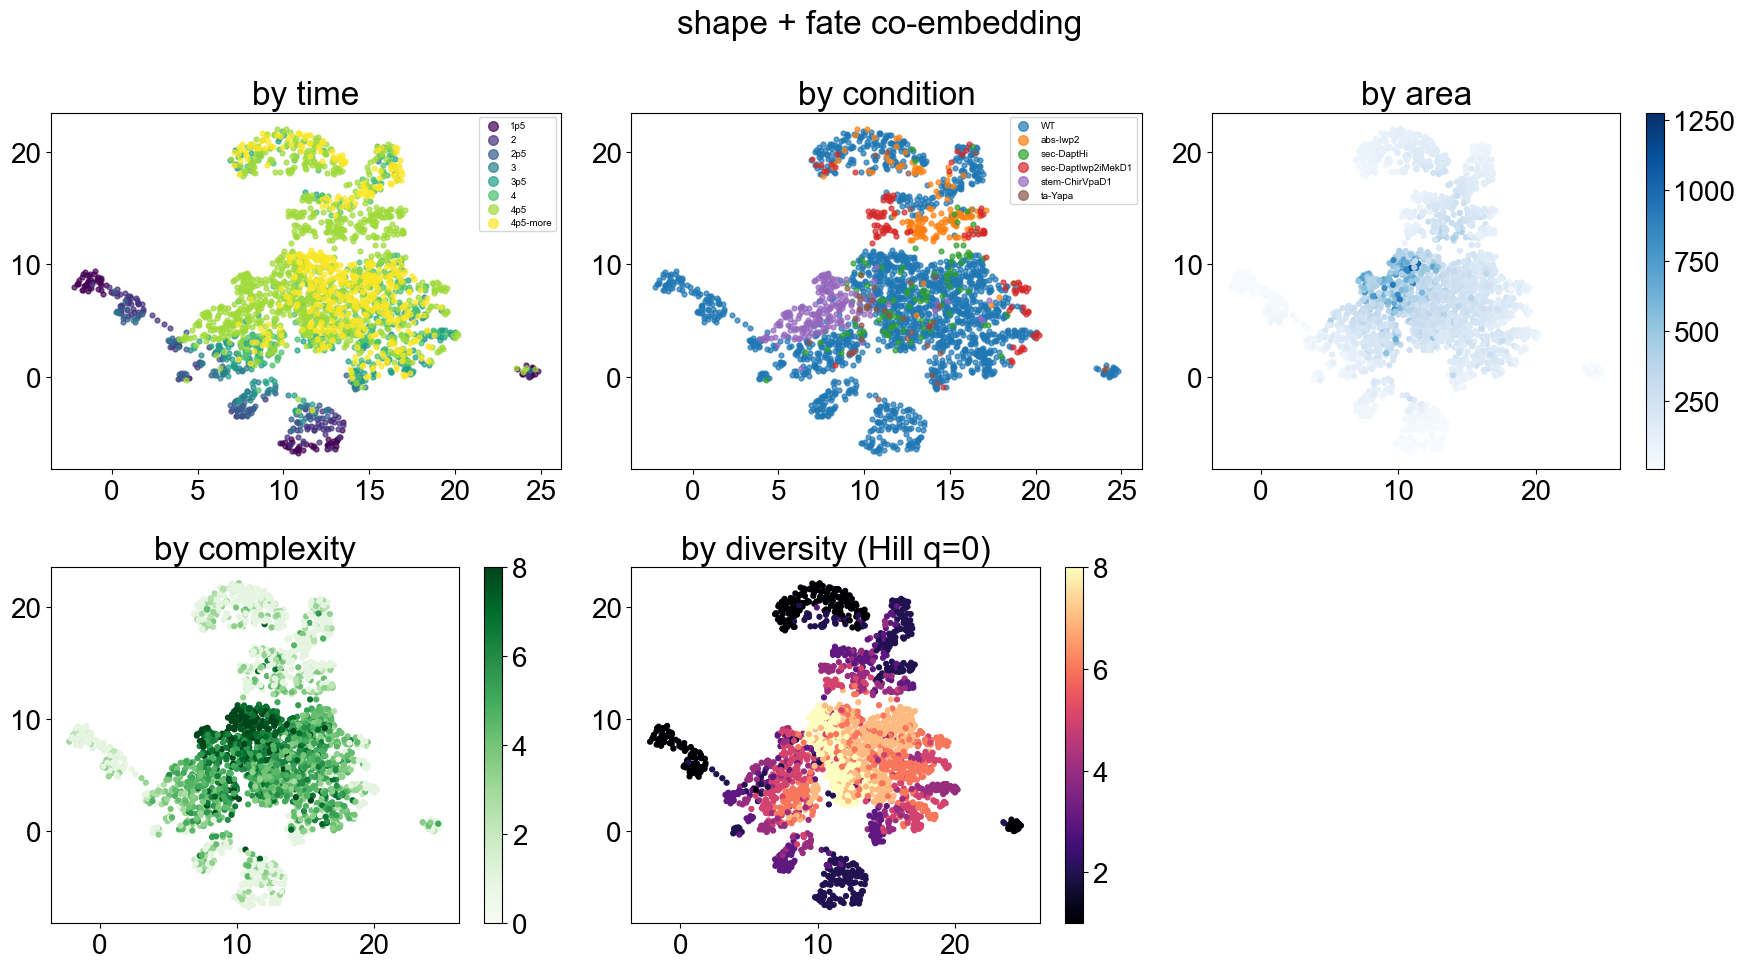

In [560]:
# --- co-embedding coloured by time / condition / area / complexity / Hill q=0 (2x3) --
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# by time (categorical)
uniq_t = np.unique(filtered_times); cmap_t = plt.get_cmap('viridis')
for i, t in enumerate(uniq_t):
    mk = filtered_times == t
    axes[0, 0].scatter(shape_fate_emb[mk, 0], shape_fate_emb[mk, 1],
                       color=cmap_t(i / max(1, len(uniq_t) - 1)), s=point_size, alpha=0.7, label=t)
axes[0, 0].set_title('by time'); axes[0, 0].legend(markerscale=2, fontsize=7)

# by condition (categorical: WT + pert drug tokens) -- the interesting one for
# checking whether perturbations separate from WT in the joint shape+fate space
uniq_c = np.unique(filtered_conditions); cmap_c = plt.get_cmap('tab10')
for i, cnd in enumerate(uniq_c):
    mk = filtered_conditions == cnd
    axes[0, 1].scatter(shape_fate_emb[mk, 0], shape_fate_emb[mk, 1],
                       color=cmap_c(i % 10), s=point_size, alpha=0.7, label=cnd)
axes[0, 1].set_title('by condition'); axes[0, 1].legend(markerscale=2, fontsize=7)

# by area
sc = axes[0, 2].scatter(*shape_fate_emb.T, c=filtered_areas, cmap='Blues', s=point_size)
axes[0, 2].set_title('by area'); fig.colorbar(sc, ax=axes[0, 2])

# by l_cross (master.npz; new max-degree scale 0..8)
sc = axes[1, 0].scatter(*shape_fate_emb.T, c=l_cross_values, cmap='Greens',
                        s=point_size, vmin=0, vmax=8)
axes[1, 0].set_title('by complexity'); fig.colorbar(sc, ax=axes[1, 0])

# by cell-type diversity (Hill q=0)
sc = axes[1, 1].scatter(*shape_fate_emb.T, c=hill[:, 0], cmap='magma', s=point_size)
axes[1, 1].set_title('by diversity (Hill q=0)'); fig.colorbar(sc, ax=axes[1, 1])

axes[1, 2].axis('off')

plt.suptitle('shape + fate co-embedding'); plt.tight_layout(); plt.show()

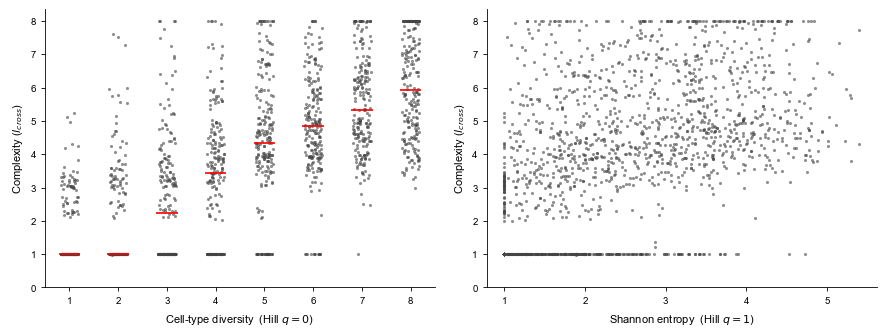

In [561]:
rng_plot = np.random.default_rng(7)

q0 = hill[:, 0].astype(int)
q1 = hill[:, 1]
diversity_levels = sorted(set(q0))
complexity_levels = sorted(set(l_cross_values.astype(int)))

plt.rcParams.update({'font.size': 20, 'font.family': 'Arial'})

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
fig.patch.set_facecolor('white')

JITTER = 0.18
PT_SIZE = 5.0
MAX_STRIP = 220

# --- left: strip plot of diversity (q=0) vs complexity ----------------------
ax = axes[0]
ax.set_facecolor('white')
for r in diversity_levels:
    vals = l_cross_values[q0 == r]
    n = min(len(vals), MAX_STRIP)
    sub = rng_plot.choice(len(vals), size=n, replace=False)
    jx = r + rng_plot.uniform(-JITTER, JITTER, size=n)
    ax.scatter(jx, vals[sub], s=PT_SIZE, color='#444444', alpha=0.6, linewidths=0, zorder=3)
    ax.hlines(np.median(vals), r - 0.22, r + 0.22, color='red', lw=1.2, zorder=4)
ax.set_xticks(diversity_levels)
ax.set_xlim(min(diversity_levels) - 0.5, max(diversity_levels) + 0.5)
ax.set_yticks(complexity_levels)
ax.set_xlabel('Cell-type diversity  (Hill $q=0$)', fontsize=8, labelpad=4)
ax.set_ylabel('Complexity ($l_{cross}$)', fontsize=8, labelpad=4)
ax.tick_params(axis='both', labelsize=7, length=3, width=0.6)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(0.6)

# --- right: scatter of exp-Shannon (q=1) vs complexity ---------------------
ax = axes[1]
ax.set_facecolor('white')
n = min(len(q1), MAX_STRIP * len(diversity_levels))
sub = rng_plot.choice(len(q1), size=n, replace=False)
ax.scatter(q1[sub], l_cross_values[sub], s=PT_SIZE, color='#444444', alpha=0.6,
           linewidths=0, zorder=3)
ax.set_xlabel('Shannon entropy  (Hill $q=1$)', fontsize=8, labelpad=4)
ax.set_ylabel('Complexity ($l_{cross}$)', fontsize=8, labelpad=4)
ax.set_yticks(complexity_levels)
ax.tick_params(axis='both', labelsize=7, length=3, width=0.6)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(0.6)

plt.tight_layout(pad=0.6)
plt.show()